# Katelyn v1 Mirror Difference

Create a `PrototypeOptimal` model with the same architecture hyperparameters as `configs/runs/optimal-prototype/katelyn-v1-images.yaml`, load the bundled test image from `hippy2d.utils.get_testing_img`, and compare mirrored versions of the image.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import ImageOps

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and (cwd.parent / "hippy2d").exists():
    project_dir = cwd.parent
elif (cwd / "hippy2d" / "hippy2d").exists():
    project_dir = cwd / "hippy2d"
elif (cwd / "hippy2d").exists():
    project_dir = cwd
else:
    raise RuntimeError(f"Could not locate the hippy2d project from {cwd}")

if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

print(project_dir)

/home/karella/Projects/rotation-invariant-neural-networks/hippy2d


## Model

These are the `m_param` values from `katelyn-v1-images.yaml`. The model below is randomly initialized; load a checkpoint before this cell if you want trained predictions.

In [2]:
from hippy2d.models import PrototypeOptimal

torch.manual_seed(42)

model_config = {
    "in_channels": 1,
    "input_size": 224,
    "kernels_size": [11, 11, 11, 11],
    "layers": [1, 2, 2, 2],
    "channels": [16, 20, 26, 32],
    "drop_rate": 0.2,
}

model = PrototypeOptimal(**model_config)
model.eval()

sum(p.numel() for p in model.parameters())

/home/karella/miniconda3/envs/hippy2d/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Got those extra arguments: {}
Got those extra arguments: {}
Got those extra arguments: {}
Got those extra arguments: {}
Got those extra arguments: {}
Got those extra arguments: {}
Got those extra arguments: {}
Got those extra arguments: {}


218536

## Load And Mirror The Test Image

In [3]:
from hippy2d.utils import get_testing_img

target_size = model_config["input_size"]

img = get_testing_img(rgb=False).convert("L").resize((target_size, target_size))
mirror_lr = ImageOps.mirror(img)

def image_to_tensor(image):
    arr = np.asarray(image, dtype=np.float32) / 255.0
    return torch.from_numpy(arr)[None, None]

images = {
    "original": image_to_tensor(img),
    "left-right mirror": image_to_tensor(mirror_lr),
    "rotated 90": image_to_tensor(img.rotate(90)),
}

batch = torch.cat(list(images.values()), dim=0)
batch.shape

torch.Size([3, 1, 224, 224])

## Pixel-Space Differences

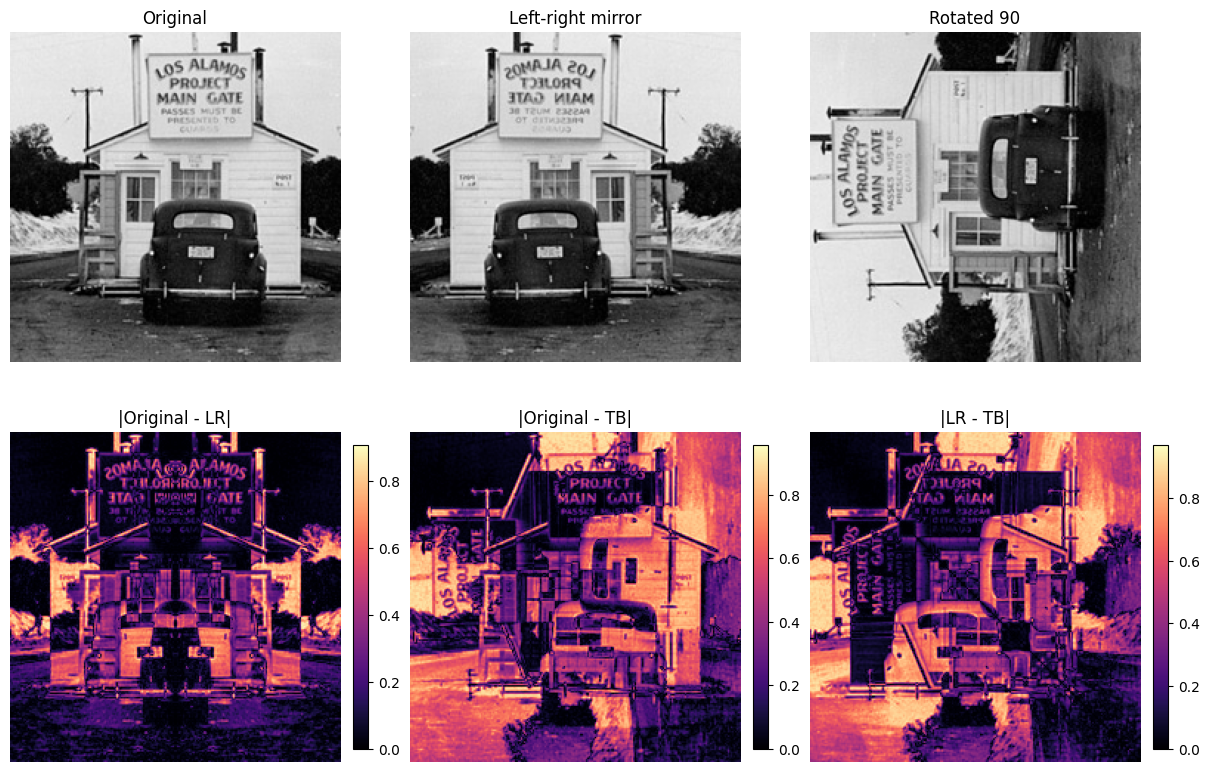

In [4]:
original = images["original"][0, 0]
lr = images["left-right mirror"][0, 0]
tb = images["rotated 90"][0, 0]

diff_original_lr = (original - lr).abs()
diff_original_tb = (original - tb).abs()
diff_lr_tb = (lr - tb).abs()

fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
panels = [
    (original, "Original", "gray"),
    (lr, "Left-right mirror", "gray"),
    (tb, "Rotated 90", "gray"),
    (diff_original_lr, "|Original - LR|", "magma"),
    (diff_original_tb, "|Original - TB|", "magma"),
    (diff_lr_tb, "|LR - TB|", "magma"),
]

for ax, (panel, title, cmap) in zip(axes.ravel(), panels):
    im = ax.imshow(panel, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    if cmap != "gray":
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

## Model-Output Differences

W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0] Graph break from `Tensor.item()`, consider setting:
W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0] or:
W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0] to include these operations in the captured graph.
W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0] 
W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0] Graph break: from user code at:
W0504 15:52:39.871000 845282 site-packages/torch/_dynamo/variables/tensor.py:1079] [0/0]   File "/home/karella/Projects/rotation-invarian

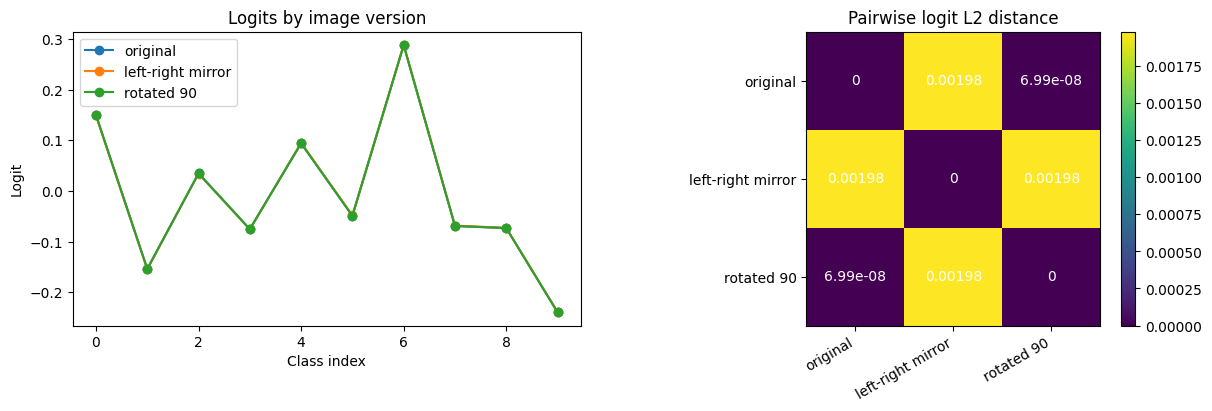

array([[0.0000000e+00, 1.9812656e-03, 6.9892643e-08],
       [1.9812656e-03, 0.0000000e+00, 1.9812600e-03],
       [6.9892643e-08, 1.9812600e-03, 0.0000000e+00]], dtype=float32)

In [5]:
with torch.inference_mode():
    logits = model(batch)

logits_np = logits.detach().cpu().numpy()
names = list(images.keys())

pairwise = np.zeros((len(names), len(names)), dtype=np.float32)
for i in range(len(names)):
    for j in range(len(names)):
        pairwise[i, j] = np.linalg.norm(logits_np[i] - logits_np[j])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(logits_np.T, marker="o")
axes[0].set_title("Logits by image version")
axes[0].set_xlabel("Class index")
axes[0].set_ylabel("Logit")
axes[0].legend(names)

im = axes[1].imshow(pairwise, cmap="viridis")
axes[1].set_title("Pairwise logit L2 distance")
axes[1].set_xticks(range(len(names)), names, rotation=30, ha="right")
axes[1].set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(names)):
        axes[1].text(j, i, f"{pairwise[i, j]:.3g}", ha="center", va="center", color="white")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()

pairwise

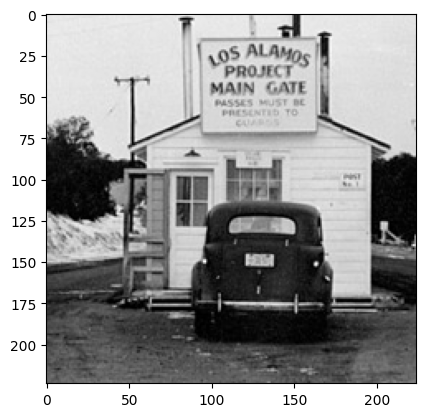

In [6]:
plt.imshow(batch[0, 0], cmap="gray")

In [7]:
moments = model.stem.moment_layer(batch)
invariants =  model.stem.invariants_layer(moments)
# Mirror the invariants back 
#invariants[1], invariants[2] = invariants[1].flip(-1), torch.rot90(invariants[2], -1, dims=(-2, -1))

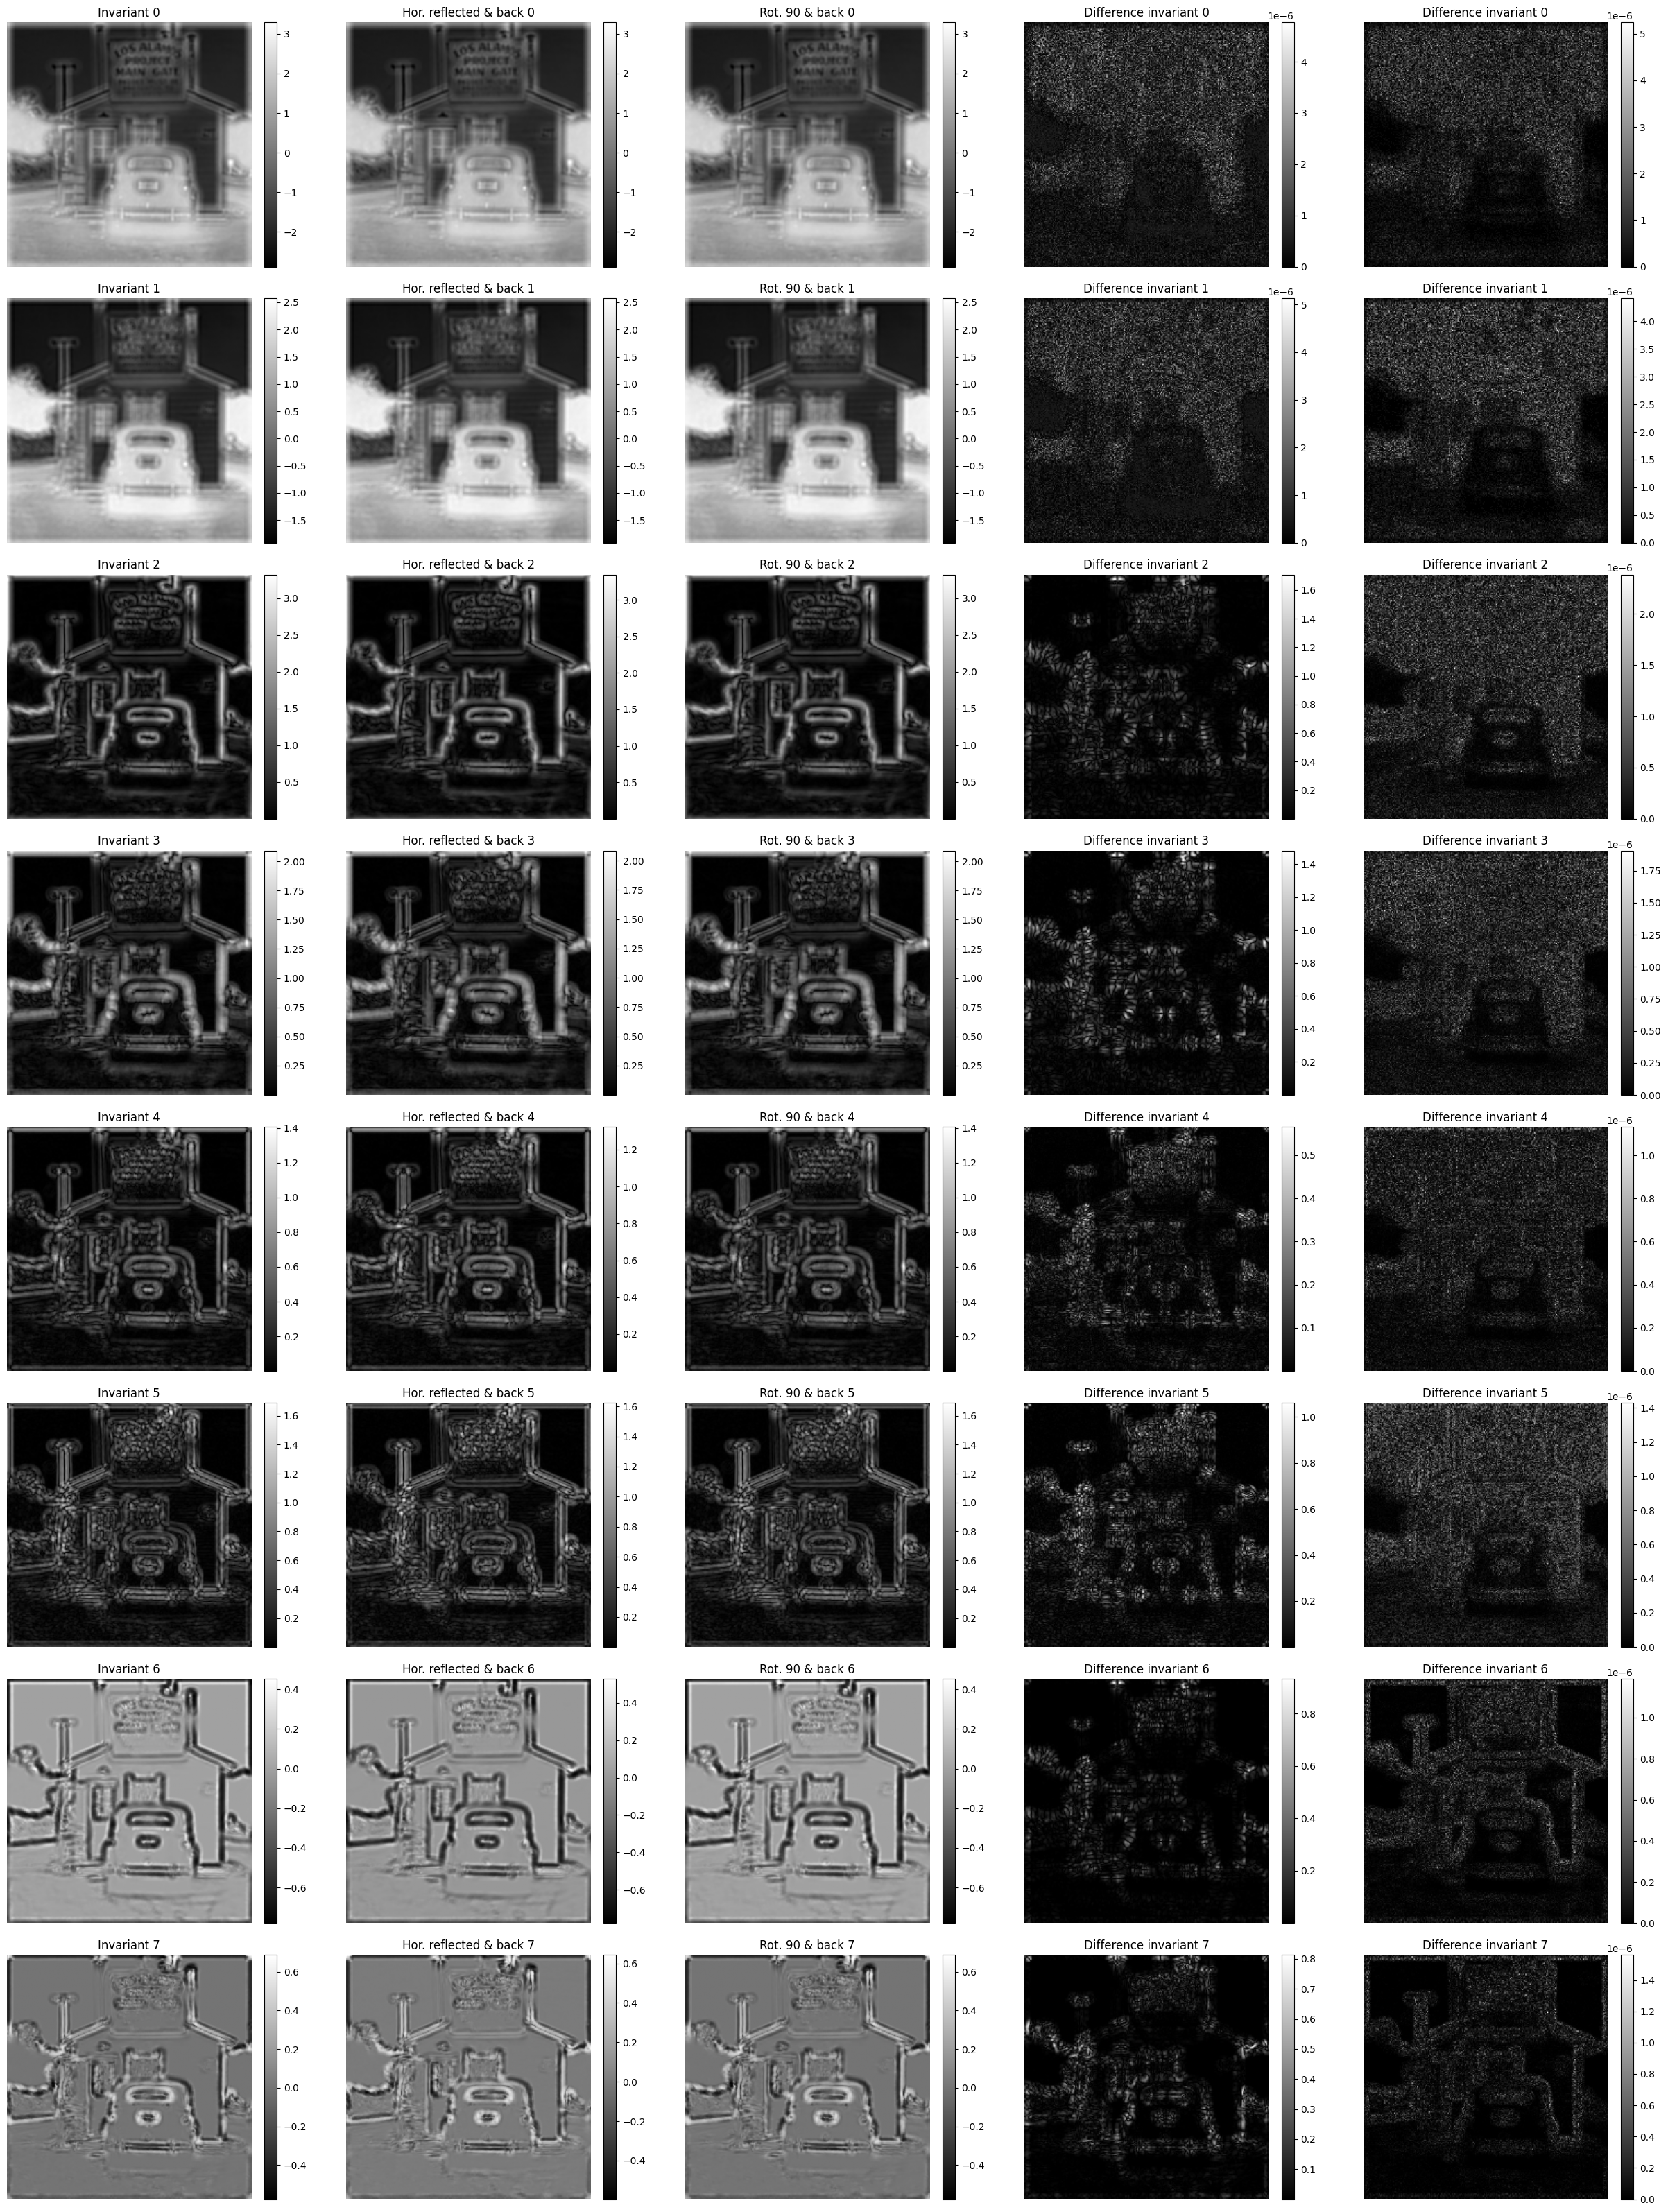

In [8]:
idxs = [0, 1, 2, 3, 4, 5, 6, 7]

inv = invariants[0]
hor_invs = invariants[1].flip(-1)
rot_invs = torch.rot90(invariants[2], -1, dims=(-2, -1))

fig, axes = plt.subplots(len(idxs), 5, figsize=(25, 4 * len(idxs)), squeeze=False)

for row, idx in enumerate(idxs):
    imgs = [
        (inv[idx], f"Invariant {idx}"),
        (hor_invs[idx], f"Hor. reflected & back {idx}"),
        (rot_invs[idx], f"Rot. 90 & back {idx}"),
        ((inv[idx] - hor_invs[idx]).abs(), f"Difference invariant {idx}"),
        ((inv[idx] - rot_invs[idx]).abs(), f"Difference invariant {idx}"),
    ]

    for col, (img, title) in enumerate(imgs):
        im = axes[row, col].imshow(img.detach().cpu(), cmap="gray")
        axes[row, col].set_title(title)
        axes[row, col].axis("off")
        fig.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


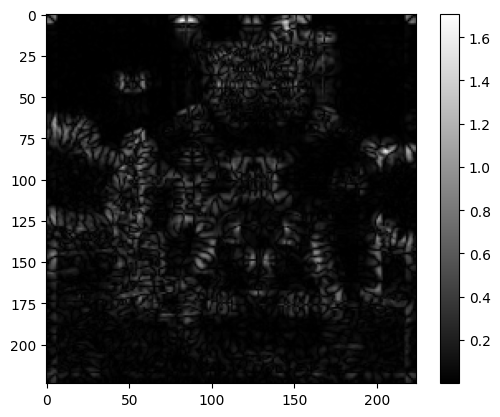

In [9]:
idx = 2
sample = inv[idx].detach().cpu()

sample_flipped = hor_invs[idx].detach().cpu()
# calculate the difference
difference = (sample - sample_flipped).abs()
plt.imshow(difference, cmap="gray")
plt.colorbar()

In [10]:
# plo